# Phase 3 — Backbone Independence on Elliptic

**Question**: Does GNN backbone complexity matter when AISO(Smart)→AISO does the heavy lifting?

| Backbone | Type | Hypothesis |
|----------|------|-----------|
| GCN | 2-layer nonlinear | Phase 1 baseline (0.6644) |
| SGC | K-step **linear** (no activation) | ≈ GCN? → low-budget² claim |
| GAT | Attention-weighted | > GCN? |
| GIN | Maximally expressive MLP | > GCN? |
| GraphSAGE | Inductive mean aggregation | ≈ GCN? |

**Final claim**: If SGC ≈ GCN (Δ < 0.01) → AISO(Smart)→AISO + SGC = 저예산에 저예산

In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv, SGConv, GATConv, GINConv
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
import copy, time
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.patches import Patch
from pathlib import Path

DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE         = Path(r'C:\Users\kevin\OneDrive\Desktop\AISO')
GAMMA        = 0.5
GNN_SEED     = 42
SEEDS        = [0, 7, 42, 77, 123]
GNN_EPOCHS   = 150
GNN_PATIENCE = 15
GNN_BUDGET   = 3

ELLIPTIC_CFG = dict(
    K_SELECT=20, N_TYPES=12,
    N_ILLICIT=1000, N_LICIT=10000, N_COMBO_TYPES=3,
)

BACKBONES = ['GCN', 'SGC', 'GAT', 'GIN', 'GraphSAGE']

print('Device:', DEVICE)

c:\Users\kevin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


In [2]:
def load_elliptic(cfg):
    ELLIPTIC_DIR = BASE / 'Elliptic Bitcoin' / 'elliptic_bitcoin_dataset'
    feat_df = pd.read_csv(str(ELLIPTIC_DIR / 'elliptic_txs_features.csv'), header=None)
    cls_df  = pd.read_csv(str(ELLIPTIC_DIR / 'elliptic_txs_classes.csv'))
    edge_df = pd.read_csv(str(ELLIPTIC_DIR / 'elliptic_txs_edgelist.csv'))

    feat_df.columns = ['txId'] + ['f%d' % i for i in range(1, 167)]
    df      = feat_df.merge(cls_df, on='txId')
    labeled = df[df['class'] != 'unknown'].copy().reset_index(drop=True)

    X      = labeled[['f%d' % i for i in range(1, 167)]].values.astype(float)
    y      = (labeled['class'] == '1').astype(int).values
    ts_all = labeled['f1'].astype(int).values

    txid_to_idx = {txid: i for i, txid in enumerate(labeled['txId'].values)}
    s_arr = edge_df.iloc[:, 0].values
    d_arr = edge_df.iloc[:, 1].values
    s_map = np.array([txid_to_idx.get(t, -1) for t in s_arr])
    d_map = np.array([txid_to_idx.get(t, -1) for t in d_arr])
    ok    = (s_map >= 0) & (d_map >= 0) & (s_map != d_map)
    src, dst = s_map[ok], d_map[ok]
    src_bi = np.concatenate([src, dst])
    dst_bi = np.concatenate([dst, src])
    edge_index = torch.tensor(np.stack([src_bi, dst_bi]), dtype=torch.long)
    ei_np = edge_index.numpy()

    N          = len(y)
    train_mask = ts_all <= 34
    test_mask  = ts_all > 34

    X_scaled          = StandardScaler().fit_transform(X)
    train_illicit_idx = np.where(train_mask & (y == 1))[0]
    train_licit_idx   = np.where(train_mask & (y == 0))[0]
    n_illicit = min(cfg['N_ILLICIT'], len(train_illicit_idx))
    n_licit   = min(cfg['N_LICIT'],   len(train_licit_idx))
    sel_n     = np.random.RandomState(GNN_SEED).choice(train_licit_idx, n_licit, replace=False)

    illicit_ratio = (y == 1).sum() / N
    print('  Elliptic: N=%d  illicit=%.1f%%  D=%d  train_illicit=%d' % (
        N, 100 * illicit_ratio, X.shape[1], len(train_illicit_idx)))

    return dict(
        X_raw=X, X_scaled=X_scaled, y=y,
        edge_index=edge_index, ei_np=ei_np,
        train_mask=train_mask, test_mask=test_mask,
        train_illicit_idx=train_illicit_idx, train_licit_idx=train_licit_idx,
        sel_n=sel_n,
        X_illicit_pool=X_scaled[train_illicit_idx],
        X_tr_all=X_scaled[train_mask],
        y_tr_all=y[train_mask],
        N_NODES=N, D=X.shape[1],
        N_ILLICIT=n_illicit, N_LICIT=n_licit,
    )


print('Loading Elliptic...')
data = load_elliptic(ELLIPTIC_CFG)

# Phase 1 reference: AISO(Smart)->AISO with GCN
P1_BEST = {'method': 'AISO(Smart)->AISO [GCN, Phase1]', 'PR_AUC': 0.6644, 'std': 0.0223}
print('Phase 1 reference: %s  PR-AUC=%.4f +/- %.4f' % (
    P1_BEST['method'], P1_BEST['PR_AUC'], P1_BEST['std']))

Loading Elliptic...
  Elliptic: N=46564  illicit=9.8%  D=166  train_illicit=3462
Phase 1 reference: AISO(Smart)->AISO [GCN, Phase1]  PR-AUC=0.6644 +/- 0.0223


In [3]:
def build_feat_M(X_tr, y_tr, N_TYPES, gamma=GAMMA):
    D = X_tr.shape[1]
    C_abs = np.abs(np.corrcoef(X_tr.T)); np.fill_diagonal(C_abs, 0.0)
    dist  = np.clip(1.0 - C_abs, 0.0, None); np.fill_diagonal(dist, 0.0)
    cl    = AgglomerativeClustering(n_clusters=N_TYPES,
                                     metric='precomputed',
                                     linkage='average').fit_predict(dist)
    MI      = mutual_info_classif(X_tr, y_tr, random_state=42)
    mean_MI = np.array([MI[cl==k].mean() if (cl==k).any() else 0.0 for k in range(N_TYPES)])
    MI_norm = (mean_MI - mean_MI.min()) / (mean_MI.max() - mean_MI.min() + 1e-8)

    def _M(mode):
        M = np.zeros((N_TYPES, N_TYPES))
        for i in range(N_TYPES):
            for j in range(N_TYPES):
                if i == j:
                    M[i][j] = -1.0
                else:
                    fi = np.where(cl==i)[0]; fj = np.where(cl==j)[0]
                    cp = -np.mean(C_abs[np.ix_(fi, fj)])
                    M[i][j] = cp + (gamma * (MI_norm[j] - MI_norm[i]) if mode == 'smart' else 0)
        return M

    return _M('smart'), _M('corr'), cl, MI


class AISOwrapperGNN:
    def __init__(self, n_agents=20, n_iter=60, beta=0.15,
                 subsample_ratio=0.15, val_ratio=0.2,
                 T_start=1.0, T_end=0.05, gnn_budget=GNN_BUDGET):
        self.n_agents = n_agents; self.n_iter = n_iter; self.beta = beta
        self.subsample_ratio = subsample_ratio; self.val_ratio = val_ratio
        self.T_start = T_start; self.T_end = T_end
        self.gnn_budget = gnn_budget

    def select(self, X_tr, y_tr, X_pool, cluster_labels, K_select, n_illicit, M, seed=42):
        rng = np.random.RandomState(seed)
        N, D = X_tr.shape; K = M.shape[0]; nb = min(3, self.n_agents - 1)
        n_pool = len(X_pool)

        val_n   = int(self.val_ratio * N)
        val_idx = rng.choice(N, val_n, replace=False)
        tr_mask = np.ones(N, bool); tr_mask[val_idx] = False
        X_val, y_val = X_tr[val_idx], y_tr[val_idx]
        X_t,   y_t   = X_tr[tr_mask], y_tr[tr_mask]
        sub_n = max(50, int(self.subsample_ratio * len(X_t)))

        cache = {}; n_calls = [0]

        def get_mask(Wi, t, explore=True):
            if explore:
                ratio  = t / max(1, self.n_iter - 1)
                T      = self.T_start * ((self.T_end / self.T_start) ** ratio)
                logits = Wi[cluster_labels] / T; logits -= logits.max()
                probs  = np.exp(logits); probs /= probs.sum()
                return tuple(rng.choice(D, K_select, replace=False, p=probs))
            else:
                return tuple(np.argsort(Wi[cluster_labels])[-K_select:])

        def get_score(mask_key, X_sub, y_sub):
            n_calls[0] += 1
            if mask_key not in cache:
                feat = list(mask_key)
                sgd  = SGDClassifier(loss='log_loss', max_iter=5, tol=None,
                                      class_weight='balanced', random_state=seed)
                try:
                    sgd.fit(X_sub[:, feat], y_sub)
                    proxy_auc = roc_auc_score(y_val, sgd.predict_proba(X_val[:, feat])[:, 1])
                    illicit_p = sgd.predict_proba(X_pool[:, feat])[:, 1]
                except Exception:
                    proxy_auc = 0.5; illicit_p = rng.rand(n_pool)
                cache[mask_key] = {'proxy_auc': proxy_auc, 'illicit_scores': illicit_p}
            return cache[mask_key]['proxy_auc']

        def top_n(mask_key):
            return np.argsort(cache[mask_key]['illicit_scores'])[-n_illicit:]

        W = rng.dirichlet(np.ones(K), self.n_agents)
        scores = np.zeros(self.n_agents)
        for i in range(self.n_agents):
            sub = rng.choice(len(X_t), sub_n, replace=False)
            mk  = get_mask(W[i], 0)
            scores[i] = get_score(mk, X_t[sub], y_t[sub])

        for t in range(self.n_iter):
            Cm = W @ M @ W.T; np.fill_diagonal(Cm, 0.0)
            sub = rng.choice(len(X_t), sub_n, replace=False)
            X_sub, y_sub = X_t[sub], y_t[sub]
            for i in range(self.n_agents):
                att   = np.argsort(Cm[i])[-nb:]
                att_s = np.array([get_score(get_mask(W[j], t), X_sub, y_sub) for j in att])
                max_s = att_s.max() + 1e-8
                bj    = att[np.argmax(Cm[i, att] * att_s / max_s)]
                W_new = (1 - self.beta) * W[i] + self.beta * W[bj]
                W[i]  = W_new / W_new.sum()
                scores[i] = get_score(get_mask(W[i], t), X_sub, y_sub)

        final_lr = LogisticRegression(solver='liblinear', C=1.0, max_iter=500,
                                       class_weight='balanced', random_state=seed)
        fseen, final_scores = {}, []
        for i in range(self.n_agents):
            mk = get_mask(W[i], self.n_iter, explore=False); feat = list(mk)
            if mk not in fseen:
                try:
                    final_lr.fit(X_t[:, feat], y_t)
                    fseen[mk] = roc_auc_score(y_val, final_lr.predict_proba(X_val[:, feat])[:, 1])
                except Exception:
                    fseen[mk] = 0.5
                if mk not in cache:
                    get_score(mk, X_t, y_t)
            final_scores.append(fseen[mk])

        seen_keys, fidelity_cands = set(), []
        for ai in np.argsort(final_scores)[::-1]:
            mk = get_mask(W[ai], self.n_iter, explore=False)
            if mk not in seen_keys and mk in cache:
                seen_keys.add(mk)
                fidelity_cands.append({'feat_mask': np.array(sorted(mk)),
                                        'top_n_local': top_n(mk),
                                        'proxy_auc': cache[mk]['proxy_auc']})
            if len(fidelity_cands) >= self.gnn_budget: break

        best_mk   = get_mask(W[np.argmax(final_scores)], self.n_iter, explore=False)
        best_feat = np.array(sorted(best_mk))
        sgd_fin   = SGDClassifier(loss='log_loss', max_iter=100, tol=1e-4,
                                   class_weight='balanced', random_state=seed)
        try:
            sgd_fin.fit(X_t[:, list(best_mk)], y_t)
            top_n_best = np.argsort(
                sgd_fin.predict_proba(X_pool[:, list(best_mk)])[:, 1])[-n_illicit:]
        except Exception:
            top_n_best = top_n(best_mk)

        return best_feat, top_n_best, {}, fidelity_cands


def run_combo_aiso_node(feat_indices, X_tr, y_tr, X_pool, N_ILLICIT,
                        N_COMBO_TYPES, seed, M_mode_2='smart'):
    X_tr_2   = X_tr[:, feat_indices]
    X_pool_2 = X_pool[:, feat_indices]
    K2       = len(feat_indices)
    nc = min(N_COMBO_TYPES, K2)
    M_smart_2, _, cl_2, _ = build_feat_M(X_tr_2, y_tr, nc)
    M_use_2 = (np.random.RandomState(seed).uniform(-0.5, 2.0, (nc, nc))
               if M_mode_2 == 'random' else M_smart_2)
    K_select_2 = max(2, K2 // 2)
    wrapper_2  = AISOwrapperGNN(n_agents=20, n_iter=60, beta=0.15,
                                T_start=1.0, T_end=0.05, gnn_budget=GNN_BUDGET)
    _, top_n_best, _, fid_cands = wrapper_2.select(
        X_tr_2, y_tr, X_pool_2, cl_2, K_select_2, N_ILLICIT, M_use_2, seed=seed)
    return fid_cands[0]['top_n_local'] if fid_cands else top_n_best


print('AISO infrastructure ready')

AISO infrastructure ready


In [4]:
def build_subgraph(top_n_illicit_local, data):
    X_scaled          = data['X_scaled']
    y_all             = data['y']
    train_illicit_idx = data['train_illicit_idx']
    sel_n             = data['sel_n']
    ei_np             = data['ei_np']
    N_NODES           = data['N_NODES']
    test_mask         = data['test_mask']

    _LU = np.full(N_NODES, -1, dtype=np.int32)

    uniq            = np.unique(top_n_illicit_local)
    sel_anom_global = train_illicit_idx[uniq]
    test_global     = np.where(test_mask)[0]
    sub_nodes       = np.unique(np.concatenate([sel_n, sel_anom_global, test_global]))
    n_sub           = len(sub_nodes)

    _LU[sub_nodes] = np.arange(n_sub)
    sl = _LU[ei_np[0]]; dl = _LU[ei_np[1]]
    ok = (sl >= 0) & (dl >= 0)
    sub_ei = torch.tensor([sl[ok], dl[ok]], dtype=torch.long).to(DEVICE)
    sub_X  = torch.from_numpy(X_scaled[sub_nodes]).float().to(DEVICE)
    sub_y  = torch.from_numpy(y_all[sub_nodes]).long().to(DEVICE)

    train_set = set(np.concatenate([sel_n, sel_anom_global]).tolist())
    test_set  = set(test_global.tolist())
    tr_gnn = torch.tensor([g in train_set for g in sub_nodes], dtype=torch.bool).to(DEVICE)
    te_gnn = torch.tensor([g in test_set  for g in sub_nodes], dtype=torch.bool).to(DEVICE)

    y_tr_sub = y_all[sub_nodes][tr_gnn.cpu().numpy()]
    n0 = int((y_tr_sub == 0).sum()); n1 = int((y_tr_sub == 1).sum())
    cw = torch.tensor([1.0, n0 / max(n1, 1)], dtype=torch.float).to(DEVICE)

    te_cpu = te_gnn.cpu().numpy()
    y_test = y_all[sub_nodes][te_cpu]

    return sub_X, sub_y, sub_ei, tr_gnn, te_gnn, cw, y_test


print('build_subgraph ready')

build_subgraph ready


In [5]:
class GCN(torch.nn.Module):
    def __init__(self, in_ch, hidden=64, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_ch, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.lin   = nn.Linear(hidden, 2)
        self.drop  = dropout

    def forward(self, x, ei):
        x = F.relu(self.conv1(x, ei))
        x = F.dropout(x, p=self.drop, training=self.training)
        x = F.relu(self.conv2(x, ei))
        x = F.dropout(x, p=self.drop, training=self.training)
        return self.lin(x)


class SGC(torch.nn.Module):
    # linear model: K-step aggregation, no nonlinearity
    def __init__(self, in_ch, hidden=64, K=2):
        super().__init__()
        self.conv = SGConv(in_ch, hidden, K=K)
        self.lin  = nn.Linear(hidden, 2)

    def forward(self, x, ei):
        return self.lin(self.conv(x, ei))


class GAT(torch.nn.Module):
    def __init__(self, in_ch, hidden=32, heads=2, dropout=0.5):
        super().__init__()
        self.conv1 = GATConv(in_ch, hidden, heads=heads, concat=True)
        self.conv2 = GATConv(hidden * heads, hidden, heads=heads, concat=True)
        self.lin   = nn.Linear(hidden * heads, 2)
        self.drop  = dropout

    def forward(self, x, ei):
        x = F.elu(self.conv1(x, ei))
        x = F.dropout(x, p=self.drop, training=self.training)
        x = F.elu(self.conv2(x, ei))
        x = F.dropout(x, p=self.drop, training=self.training)
        return self.lin(x)


class GIN(torch.nn.Module):
    def __init__(self, in_ch, hidden=64, dropout=0.5):
        super().__init__()
        mlp1 = nn.Sequential(nn.Linear(in_ch, hidden), nn.ReLU(), nn.Linear(hidden, hidden))
        mlp2 = nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, hidden))
        self.conv1 = GINConv(mlp1)
        self.conv2 = GINConv(mlp2)
        self.lin   = nn.Linear(hidden, 2)
        self.drop  = dropout

    def forward(self, x, ei):
        x = F.relu(self.conv1(x, ei))
        x = F.dropout(x, p=self.drop, training=self.training)
        x = F.relu(self.conv2(x, ei))
        x = F.dropout(x, p=self.drop, training=self.training)
        return self.lin(x)


class GraphSAGE(torch.nn.Module):
    def __init__(self, in_ch, hidden=64, dropout=0.5):
        super().__init__()
        self.conv1 = SAGEConv(in_ch, hidden)
        self.conv2 = SAGEConv(hidden, hidden)
        self.lin   = nn.Linear(hidden, 2)
        self.drop  = dropout

    def forward(self, x, ei):
        x = F.relu(self.conv1(x, ei))
        x = F.dropout(x, p=self.drop, training=self.training)
        x = F.relu(self.conv2(x, ei))
        x = F.dropout(x, p=self.drop, training=self.training)
        return self.lin(x)


MODEL_FACTORY = {
    'GCN':       lambda in_ch: GCN(in_ch),
    'SGC':       lambda in_ch: SGC(in_ch),
    'GAT':       lambda in_ch: GAT(in_ch),
    'GIN':       lambda in_ch: GIN(in_ch),
    'GraphSAGE': lambda in_ch: GraphSAGE(in_ch),
}


def evaluate_backbone(model_name, sub_X, sub_y, sub_ei, tr_gnn, te_gnn, cw, y_test,
                      seed=GNN_SEED):
    torch.manual_seed(seed)
    model = MODEL_FACTORY[model_name](sub_X.shape[1]).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

    best_loss, best_state, patience = float('inf'), None, 0
    for _ in range(GNN_EPOCHS):
        model.train(); opt.zero_grad()
        loss = F.cross_entropy(model(sub_X, sub_ei)[tr_gnn], sub_y[tr_gnn], weight=cw)
        loss.backward(); opt.step()
        if loss.item() < best_loss:
            best_loss = loss.item()
            best_state = copy.deepcopy(model.state_dict())
            patience = 0
        else:
            patience += 1
        if patience >= GNN_PATIENCE:
            break

    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        prob = F.softmax(model(sub_X, sub_ei), dim=1)[:, 1].cpu().numpy()

    prob_te = prob[te_gnn.cpu().numpy()]
    return {
        'PR-AUC': average_precision_score(y_test, prob_te),
        'F1':     f1_score(y_test, (prob_te >= 0.5).astype(int), zero_division=0),
        'AUC':    roc_auc_score(y_test, prob_te),
    }


print('All backbones ready:', BACKBONES)

All backbones ready: ['GCN', 'SGC', 'GAT', 'GIN', 'GraphSAGE']


In [6]:
cfg    = ELLIPTIC_CFG
X_tr   = data['X_tr_all']
y_tr   = data['y_tr_all']
X_pool = data['X_illicit_pool']

# Build Smart M once (seed-independent clustering)
print('Building stage-1 Smart M...')
M_smart_1, _, cl_1, _ = build_feat_M(X_tr, y_tr, cfg['N_TYPES'])
wrapper_1 = AISOwrapperGNN(n_agents=20, n_iter=60, beta=0.15,
                            T_start=1.0, T_end=0.05, gnn_budget=GNN_BUDGET)

p3_results = {bb: [] for bb in BACKBONES}

for seed in SEEDS:
    print()
    print('=== seed=%d ===' % seed)
    t_seed = time.time()

    # Stage 1: AISO feature selection with Smart M
    print('  [Stage 1] AISO feature selection...', end='', flush=True)
    t0 = time.time()
    feat_idx, _, _, _ = wrapper_1.select(
        X_tr, y_tr, X_pool, cl_1, cfg['K_SELECT'], cfg['N_ILLICIT'], M_smart_1, seed=seed)
    print(' %.0fs  top feats=%s' % (time.time() - t0, feat_idx[:5].tolist()))

    # Stage 2: AISO node selection with Smart M on selected features
    print('  [Stage 2] AISO node selection (Smart M)...', end='', flush=True)
    t0 = time.time()
    top_n_local = run_combo_aiso_node(
        feat_idx, X_tr, y_tr, X_pool,
        cfg['N_ILLICIT'], cfg['N_COMBO_TYPES'], seed, M_mode_2='smart')
    print(' %.0fs  n_illicit=%d' % (time.time() - t0, len(np.unique(top_n_local))))

    # Build subgraph — same for all backbones within this seed
    sub_X, sub_y, sub_ei, tr_gnn, te_gnn, cw, y_test = build_subgraph(top_n_local, data)
    print('  Subgraph: %d nodes  %d undirected edges' % (
        sub_X.shape[0], sub_ei.shape[1] // 2))

    # Evaluate each backbone on the same subgraph
    for bb in BACKBONES:
        t0 = time.time()
        r  = evaluate_backbone(bb, sub_X, sub_y, sub_ei, tr_gnn, te_gnn, cw, y_test, seed=seed)
        r['seed'] = seed
        p3_results[bb].append(r)
        print('  %-12s PR-AUC=%.4f  F1=%.4f  %.0fs' % (
            bb, r['PR-AUC'], r['F1'], time.time() - t0))

    print('  seed total: %.0fs' % (time.time() - t_seed))

print()
print('>>> Phase 3 complete')

Building stage-1 Smart M...

=== seed=0 ===
  [Stage 1] AISO feature selection... 126s  top feats=[2, 4, 5, 6, 7]
  [Stage 2] AISO node selection (Smart M)... 90s  n_illicit=1000
  Subgraph: 27670 nodes  16741 undirected edges
  GCN          PR-AUC=0.6777  F1=0.6549  36s
  SGC          PR-AUC=0.1815  F1=0.2840  15s
  GAT          PR-AUC=0.6812  F1=0.7285  55s
  GIN          PR-AUC=0.5316  F1=0.5656  25s
  GraphSAGE    PR-AUC=0.6742  F1=0.7248  21s
  seed total: 368s

=== seed=7 ===
  [Stage 1] AISO feature selection... 81s  top feats=[5, 14, 15, 88, 94]
  [Stage 2] AISO node selection (Smart M)... 59s  n_illicit=1000
  Subgraph: 27670 nodes  16710 undirected edges
  GCN          PR-AUC=0.6632  F1=0.6327  42s
  SGC          PR-AUC=0.3888  F1=0.4141  18s
  GAT          PR-AUC=0.6796  F1=0.6938  28s
  GIN          PR-AUC=0.5703  F1=0.5748  18s
  GraphSAGE    PR-AUC=0.6813  F1=0.7114  25s
  seed total: 270s

=== seed=42 ===
  [Stage 1] AISO feature selection... 74s  top feats=[2, 4, 5, 6, 


  Phase 3 -- Elliptic: AISO(Smart)->AISO + 5 Backbones
  Backbone         PR-AUC     std       F1
  ------------------------------------------
  GCN              0.6608  0.0121   0.6366
  SGC              0.3175  0.0733   0.3737
  GAT              0.6382  0.0609   0.6842
  GIN              0.5493  0.0308   0.5126
  GraphSAGE        0.6611  0.0212   0.6945
  ------------------------------------------
  GCN [P1]         0.6644  0.0223  (Phase 1 GCN reference)

SGC vs GCN: 0.3175 - 0.6608 = -0.3433
=> SGC < GCN (delta=-0.3433)  Nonlinearity adds value at this scale.

Saved: phase3_elliptic_results.csv


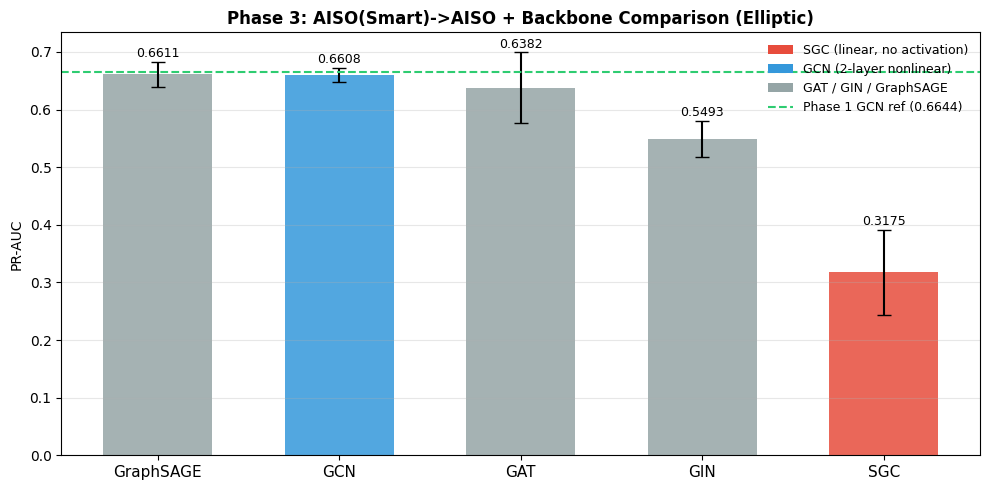

Saved: phase3_elliptic.png


In [7]:
print()
print('=' * 62)
print('  Phase 3 -- Elliptic: AISO(Smart)->AISO + 5 Backbones')
print('=' * 62)
print('  %-14s %8s %7s %8s' % ('Backbone', 'PR-AUC', 'std', 'F1'))
print('  ' + '-' * 42)

summary = {}
for bb in BACKBONES:
    rl      = p3_results[bb]
    prs     = [r['PR-AUC'] for r in rl]
    f1s     = [r['F1']     for r in rl]
    mean_pr = np.mean(prs); std_pr = np.std(prs); mean_f1 = np.mean(f1s)
    summary[bb] = dict(PR_AUC=mean_pr, std=std_pr, F1=mean_f1)
    print('  %-14s %8.4f %7.4f %8.4f' % (bb, mean_pr, std_pr, mean_f1))

print('  ' + '-' * 42)
print('  %-14s %8.4f %7.4f  (Phase 1 GCN reference)' % (
    'GCN [P1]', P1_BEST['PR_AUC'], P1_BEST['std']))

gcn_pr = summary['GCN']['PR_AUC']
sgc_pr = summary['SGC']['PR_AUC']
delta  = sgc_pr - gcn_pr
print()
print('SGC vs GCN: %.4f - %.4f = %+.4f' % (sgc_pr, gcn_pr, delta))
if abs(delta) < 0.01:
    print('=> CONFIRMED: SGC ~= GCN (delta < 0.01)  Low-budget^2 claim holds.')
elif delta > 0.01:
    print('=> SGC > GCN  Linear aggregation sufficient or better.')
else:
    print('=> SGC < GCN (delta=%.4f)  Nonlinearity adds value at this scale.' % delta)

# Save CSV
rows = []
for bb, rl in p3_results.items():
    for r in rl:
        rows.append({'backbone': bb, 'seed': r['seed'],
                     'PR-AUC': r['PR-AUC'], 'F1': r['F1'], 'AUC': r['AUC']})
df_p3 = pd.DataFrame(rows)
df_p3.to_csv(BASE / 'phase3_elliptic_results.csv', index=False)
print()
print('Saved: phase3_elliptic_results.csv')

# Plot
bb_order = sorted(BACKBONES, key=lambda b: summary[b]['PR_AUC'], reverse=True)
means  = [summary[b]['PR_AUC'] for b in bb_order]
stds   = [summary[b]['std']    for b in bb_order]
colors = ['#e74c3c' if b == 'SGC' else '#3498db' if b == 'GCN' else '#95a5a6'
          for b in bb_order]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(np.arange(len(bb_order)), means, yerr=stds, capsize=5,
       color=colors, alpha=0.85, width=0.6)
ax.axhline(P1_BEST['PR_AUC'], color='#2ecc71', linestyle='--', linewidth=1.5)
ax.set_xticks(np.arange(len(bb_order)))
ax.set_xticklabels(bb_order, fontsize=11)
ax.set_ylabel('PR-AUC')
ax.set_title('Phase 3: AISO(Smart)->AISO + Backbone Comparison (Elliptic)',
             fontweight='bold')
ax.grid(alpha=0.3, axis='y')
for xi, (mv, sv) in enumerate(zip(means, stds)):
    ax.text(xi, mv + sv + 0.003, '%.4f' % mv, ha='center', va='bottom', fontsize=9)

ref_line = mlines.Line2D([], [], color='#2ecc71', linestyle='--', linewidth=1.5,
                          label='Phase 1 GCN ref (%.4f)' % P1_BEST['PR_AUC'])
legend_elements = [
    Patch(facecolor='#e74c3c', label='SGC (linear, no activation)'),
    Patch(facecolor='#3498db', label='GCN (2-layer nonlinear)'),
    Patch(facecolor='#95a5a6', label='GAT / GIN / GraphSAGE'),
    ref_line,
]
ax.legend(handles=legend_elements, frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig(BASE / 'phase3_elliptic.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: phase3_elliptic.png')